# Country Intelligence System using Clustering and Ensemble Learning

**Objective:** Develop an end-to-end country intelligence system using clustering, classification, and ensemble learning techniques to analyze socio-economic indicators, identify meaningful country segments, and generate actionable development insights.

**Dataset:** Country Data containing socio-economic and health indicators for 167 countries, including income, GDP per capita, inflation, life expectancy, and child mortality.

---

## 1. Introduction

### Project Overview

This project develops a **Country Intelligence System** using machine learning techniques. The goal is to group countries based on socio-economic indicators and build models to classify countries into these groups.

### Techniques Used

- **K-Means Clustering**
- **DBSCAN Clustering**
- **Random Forest Classifier**
- **XGBoost Classifier**

### Workflow

Raw Data → Preprocessing → Clustering → Classification → Evaluation → Insights

### Objective

- Segment countries into meaningful clusters.
- Predict cluster membership using classification models.
- Compare ensemble learning methods.
- Generate insights from country-level socio-economic data.

## 2. Import Libraries & Set Configuration


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, silhouette_score,
    davies_bouldin_score
)

# Clustering
from sklearn.cluster import KMeans, DBSCAN

# Classification Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully!")
print(f"✓ Random State Set: 42")

✓ All libraries imported successfully!
✓ Random State Set: 42


## 3. Load Dataset


In [22]:
df = pd.read_csv('Country-data.csv')

print("="*50)
print("DATASET OVERVIEW")
print("="*50)

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nFirst 5 Rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

DATASET OVERVIEW
Shape: (167, 10)
Rows: 167
Columns: 10

First 5 Rows:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200



Column Names:
['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


### Observations

- The dataset contains socio-economic and health indicators for 167 countries.
- There are 10 columns, including one country identifier column and multiple numerical features.
- These features will be used for clustering and classification tasks.

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


### Observations

- Only the `country` column is categorical, while the remaining features are numerical.
- No missing values are present in the dataset.

## 4. Exploratory Data Analysis (EDA)


In [24]:
# Missing Values Analysis

print("="*50)
print("MISSING VALUES ANALYSIS")
print("="*50)

missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': (missing_values / len(df)) * 100
})

display(missing_df)

# Descriptive Statistics

print("\n" + "="*50)
print("DESCRIPTIVE STATISTICS")
print("="*50)

display(df.describe().round(2))

MISSING VALUES ANALYSIS


,Missing Values,Percentage
country,0,0.0
child_mort,0,0.0
exports,0,0.0
health,0,0.0
imports,0,0.0
income,0,0.0
inflation,0,0.0
life_expec,0,0.0
total_fer,0,0.0
gdpp,0,0.0



DESCRIPTIVE STATISTICS


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


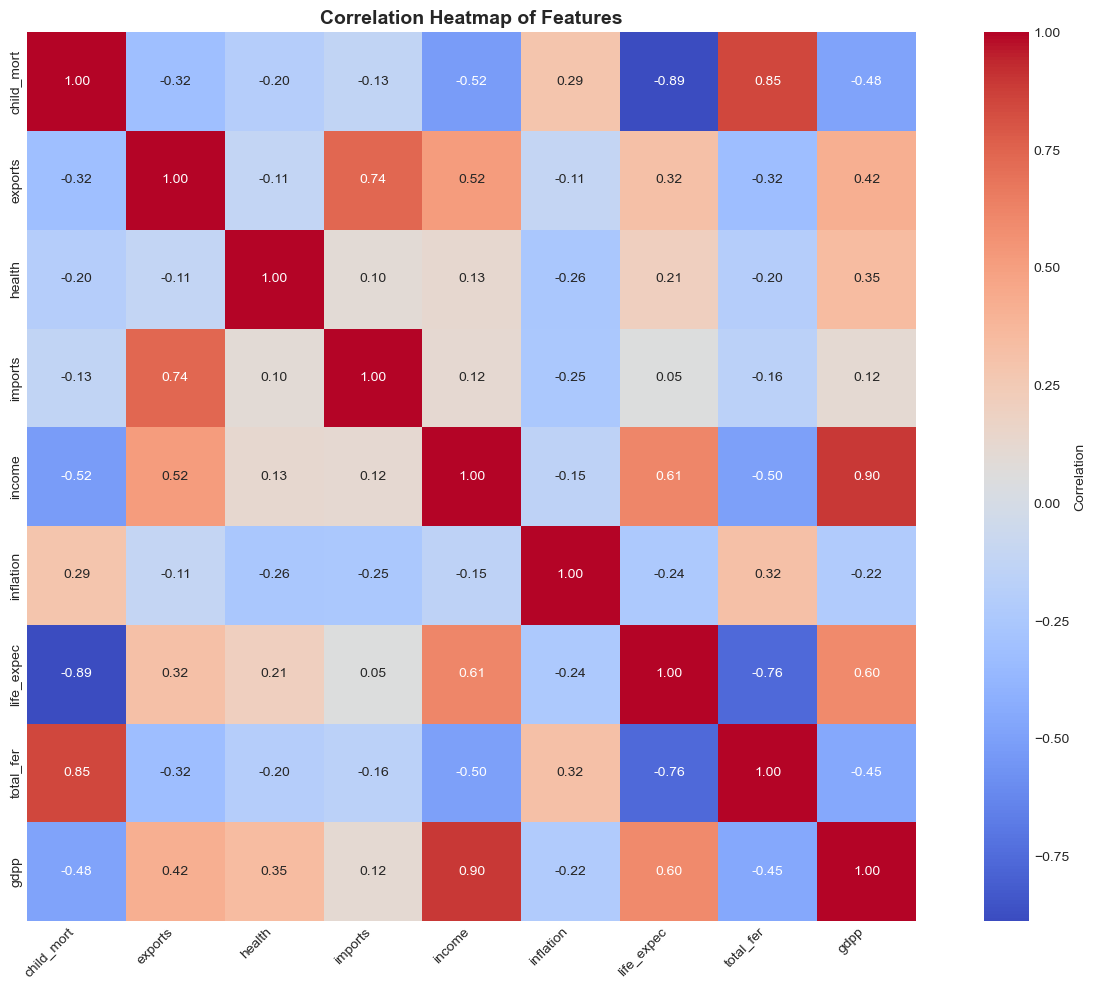

In [25]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(14, 10))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, cbar_kws={'label': 'Correlation'}, ax=ax)
plt.title('Correlation Heatmap of Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Observations

- Income and GDP per capita show a very strong positive correlation (0.90), indicating that wealthier countries generally have higher economic output.
- Child mortality and life expectancy have a strong negative correlation (-0.89), suggesting that countries with lower child mortality tend to have longer life expectancy.
- Child mortality and fertility rate are strongly positively correlated (0.85).
- Life expectancy and fertility rate show a strong negative relationship (-0.76).
- These relationships indicate that economic and health indicators play an important role in distinguishing country groups and will influence clustering results.

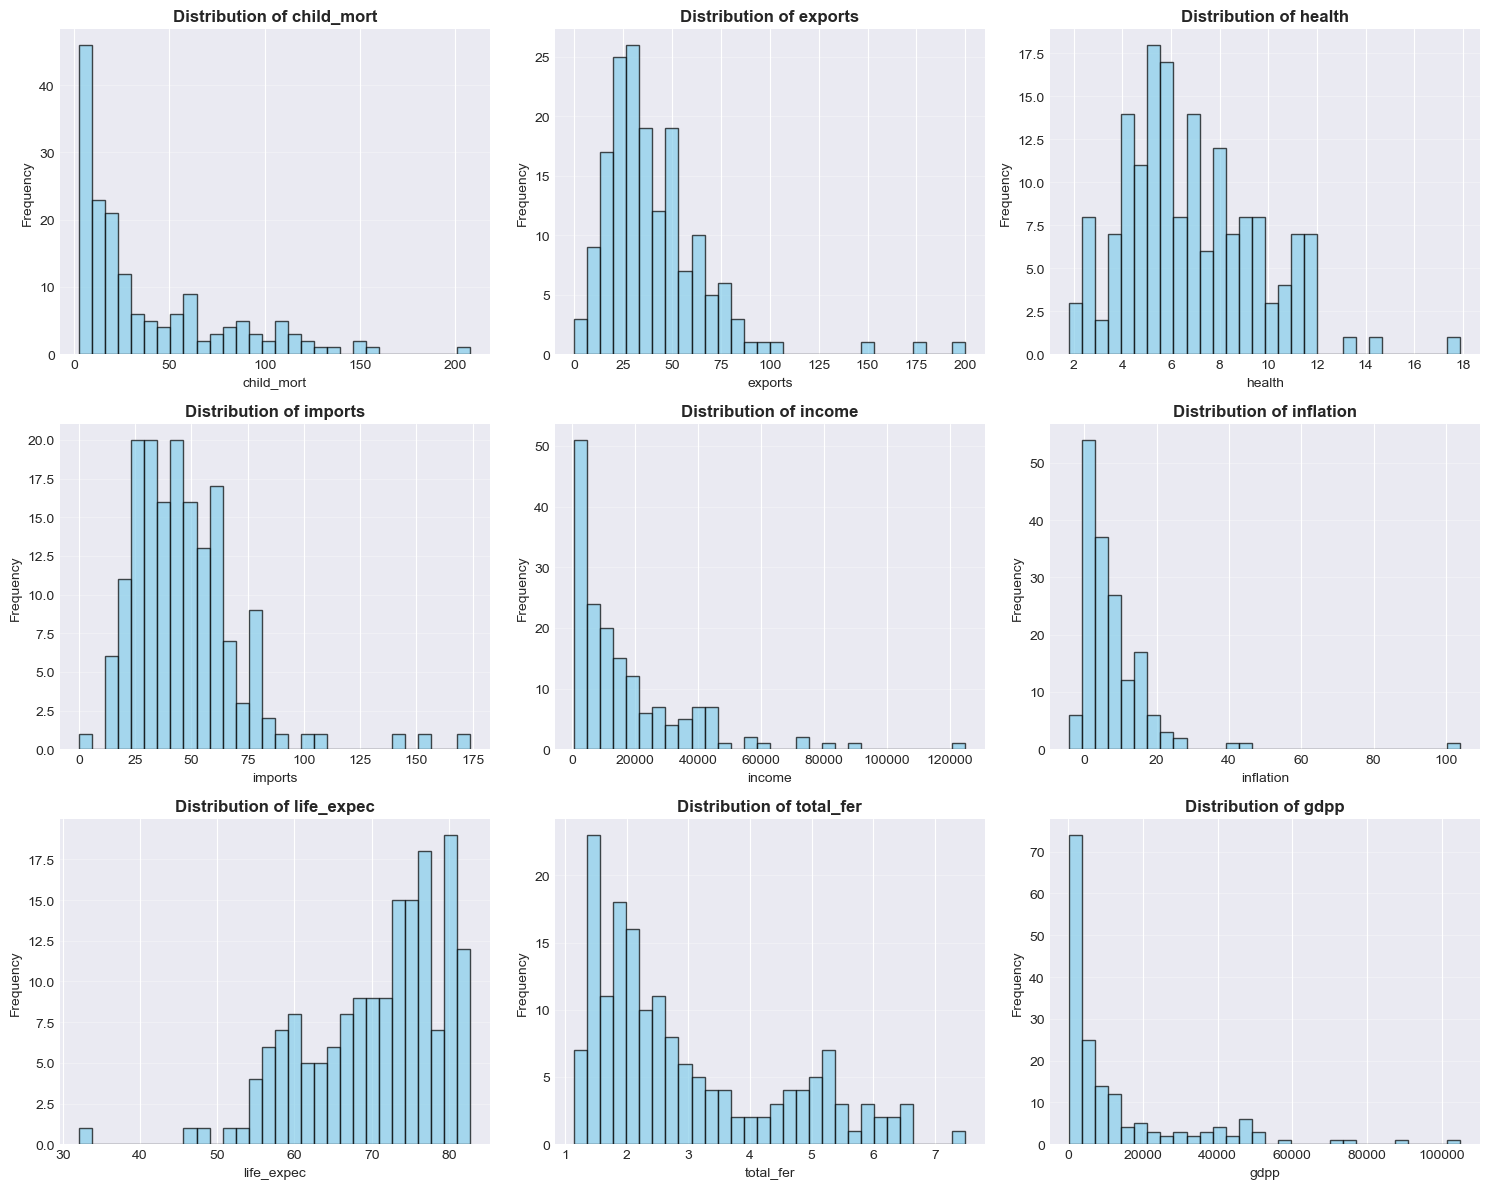

In [26]:
# Distribution Analysis - Histograms
numeric_cols = df.select_dtypes(include=[np.number]).columns
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

# Hide extra subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


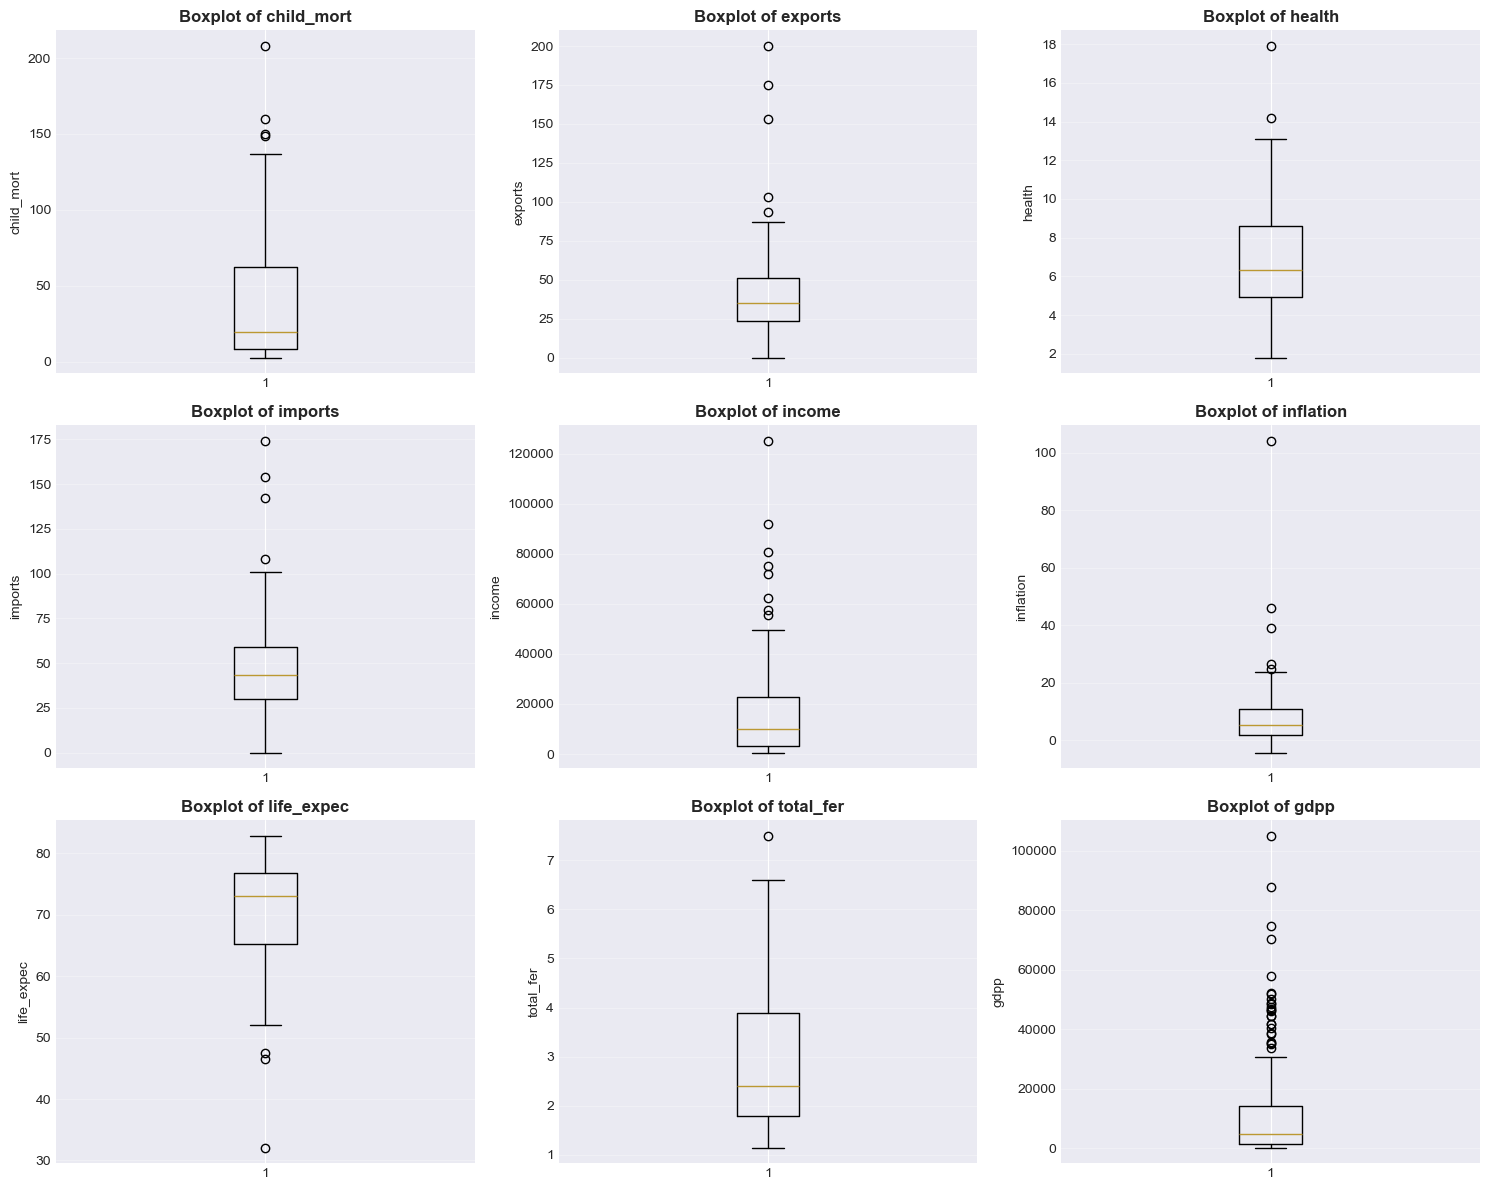

In [27]:
# Boxplots for Outlier Detection
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    axes[idx].boxplot(df[col], vert=True)
    axes[idx].set_title(f'Boxplot of {col}', fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(axis='y', alpha=0.3)

# Hide extra subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


## 5. Data Preprocessing


In [28]:
# Store country names separately
country_names = df['country']

# Select only numeric features
X = df.select_dtypes(include=[np.number])

print(f"Feature Matrix Shape: {X.shape}")
print("\nFeatures Used:")
print(X.columns.tolist())

Feature Matrix Shape: (167, 9)

Features Used:
['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


In [29]:
# Standardize Features using StandardScaler
# Scaling is important because clustering algorithms are distance-based.
# It ensures that all features contribute equally to the analysis.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("✓ Features scaled successfully")
print(f"Scaled Data Shape: {X_scaled.shape}")

✓ Features scaled successfully
Scaled Data Shape: (167, 9)


## 6. K-Means Clustering


In [30]:
# Elbow Method and Silhouette Score

wcss = []
silhouette_scores = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

    if k > 1:
        silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    else:
        silhouette_scores.append(0)

# Results Table
elbow_results = pd.DataFrame({
    'k': range(1, 11),
    'WCSS': wcss,
    'Silhouette Score': silhouette_scores
})

display(elbow_results)

,k,WCSS,Silhouette Score
0,1,1503.000000,0.000000
1,2,1050.214558,0.287357
2,3,831.424435,0.283296
3,4,700.520537,0.295952
4,5,620.163371,0.299259
5,6,558.469660,0.228692
6,7,495.807946,0.247681
7,8,457.586148,0.238811
8,9,427.803672,0.207312
9,10,403.229613,0.202230


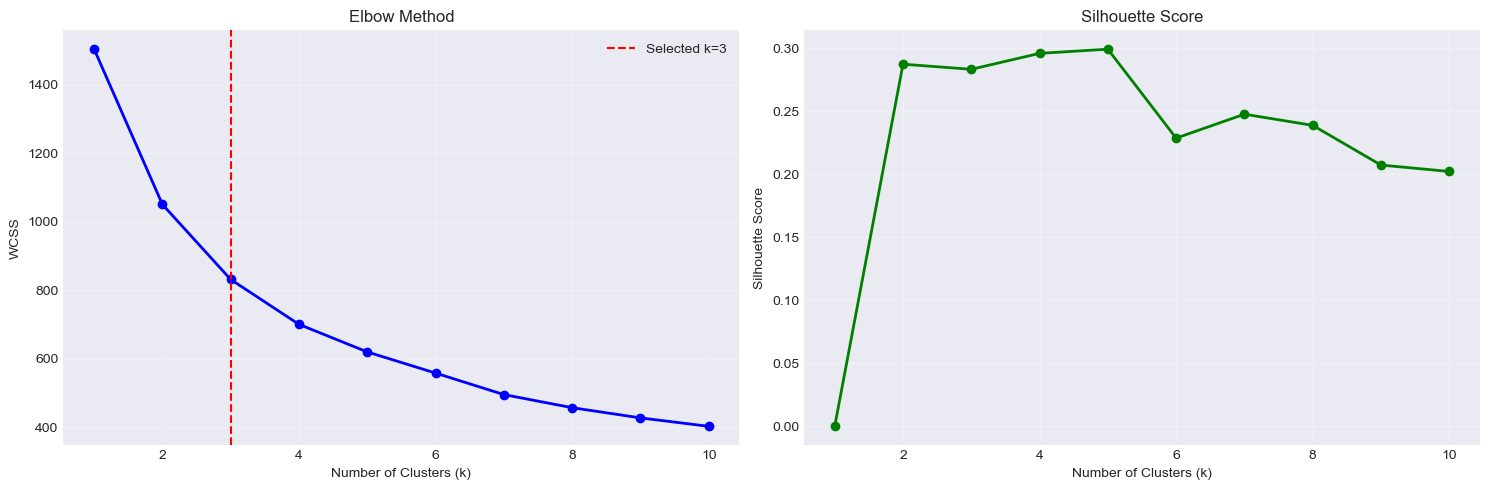

In [31]:
# Visualize Elbow Curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow Curve
ax1.plot(range(1, 11), wcss, 'bo-', linewidth=2)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS')
ax1.set_title('Elbow Method')
ax1.axvline(x=3, color='red', linestyle='--', label='Selected k=3')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Silhouette Score
ax2.plot(range(1, 11), silhouette_scores, 'go-', linewidth=2)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
# Train K-Means with Optimal Number of Clusters

optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

# Store cluster labels
df['kmeans_cluster'] = kmeans_labels

print(f"K-Means clustering completed with {optimal_k} clusters")
print("\nCluster Distribution:")
print(df['kmeans_cluster'].value_counts().sort_index())

K-Means clustering completed with 3 clusters

Cluster Distribution:
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64


In [33]:
# Evaluate K-Means Clustering

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_davies_bouldin = davies_bouldin_score(X_scaled, kmeans_labels)

print("K-MEANS EVALUATION")
print("=" * 40)
print(f"Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Davies-Bouldin Index: {kmeans_davies_bouldin:.4f}")
print(f"Inertia (WCSS): {kmeans.inertia_:.2f}")

K-MEANS EVALUATION
Silhouette Score: 0.2833
Davies-Bouldin Index: 1.2769
Inertia (WCSS): 831.42


PCA Results:
Explained Variance Ratio: [0.4595174  0.17181626]
Total Variance Explained: 63.13%


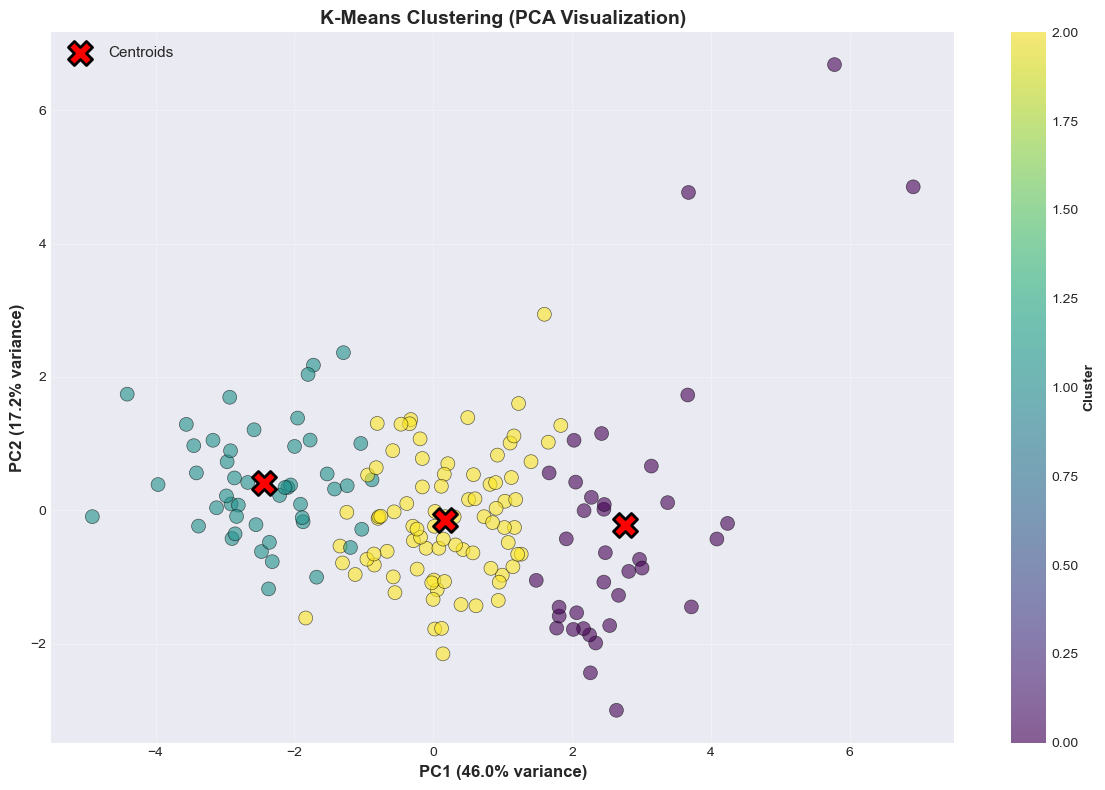

In [34]:
# Visualize K-Means Clusters using PCA
# PCA reduces 9 dimensions to 2 for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA Results:")
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Variance Explained: {sum(pca.explained_variance_ratio_):.2%}")

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', 
                     s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', 
          s=300, edgecolors='black', linewidth=2, label='Centroids')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12, fontweight='bold')
ax.set_title('K-Means Clustering (PCA Visualization)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Cluster', fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7. DBSCAN Clustering


In [35]:
# Step 1: Train DBSCAN with different parameters
# DBSCAN Parameters:
# - eps: Maximum distance between points in a cluster
# - min_samples: Minimum points to form a core point

# Experiment with different parameter combinations
dbscan_results = []

eps_values = [0.5, 0.7, 0.9, 1.1]
min_samples_values = [3, 5, 7]

print("Testing DBSCAN Parameter Combinations...\n")
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan_labels = dbscan.fit_predict(X_scaled)
        
        n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
        n_noise = list(dbscan_labels).count(-1)
        
        # Silhouette score only if valid clusters exist
        if n_clusters > 1 and n_noise < len(dbscan_labels) - 1:
            sil_score = silhouette_score(X_scaled, dbscan_labels)
        else:
            sil_score = -1
        
        dbscan_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': sil_score
        })

dbscan_df = pd.DataFrame(dbscan_results)
display(dbscan_df)

Testing DBSCAN Parameter Combinations...



,eps,min_samples,n_clusters,n_noise,silhouette
0,0.5,3,1,162,-1.000000
1,0.5,5,0,167,-1.000000
2,0.5,7,0,167,-1.000000
3,0.7,3,8,137,-0.324139
4,0.7,5,1,162,-1.000000
5,0.7,7,0,167,-1.000000
6,0.9,3,4,100,-0.134613
7,0.9,5,3,119,-0.044566
8,0.9,7,3,140,-0.217144
9,1.1,3,4,58,0.088629


In [36]:
# Step 2: Train DBSCAN with selected parameters

dbscan = DBSCAN(eps=1.1, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Store labels
df['dbscan_cluster'] = dbscan_labels

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print("DBSCAN RESULTS")
print("=" * 40)
print(f"Clusters Found: {n_clusters}")
print(f"Noise Points: {n_noise}")
print(f"Noise Percentage: {(n_noise/len(dbscan_labels))*100:.1f}%")

DBSCAN RESULTS
Clusters Found: 4
Noise Points: 58
Noise Percentage: 34.7%


In [37]:
# Step 3: Evaluate DBSCAN
n_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_dbscan_noise = list(dbscan_labels).count(-1)

if n_dbscan_clusters > 1:
    dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels)
    dbscan_davies_bouldin = davies_bouldin_score(X_scaled, dbscan_labels)
    
    print("DBSCAN EVALUATION METRICS")
    print("="*60)
    print(f"Silhouette Score: {dbscan_silhouette:.4f}")
    print(f"Davies-Bouldin Index: {dbscan_davies_bouldin:.4f}")
else:
    print("Note: Unable to calculate silhouette score (insufficient clusters)")

DBSCAN EVALUATION METRICS
Silhouette Score: 0.0886
Davies-Bouldin Index: 2.1611


### Observation

DBSCAN produced a negative silhouette score and a higher Davies-Bouldin Index compared to K-Means. Additionally, it classified many countries as noise points. Therefore, K-Means provided more meaningful and well-separated clusters for this dataset.

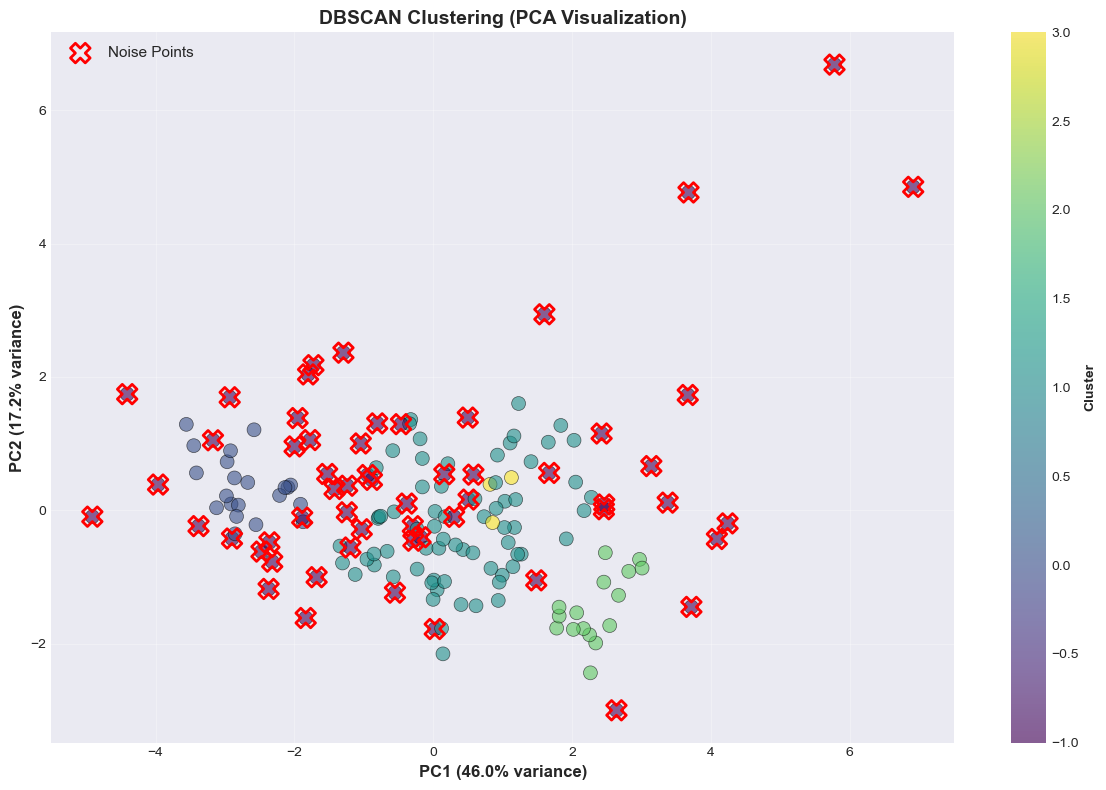

In [38]:
# Step 4: Visualize DBSCAN Clusters
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis', 
                     s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

# Highlight noise points
noise_mask = dbscan_labels == -1
if noise_mask.any():
    ax.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], 
              marker='X', s=200, edgecolors='red', linewidth=2, 
              facecolors='none', label='Noise Points')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12, fontweight='bold')
ax.set_title('DBSCAN Clustering (PCA Visualization)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Cluster', fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [39]:
comparison = pd.DataFrame({
    'Metric': ['Clusters', 'Noise Points', 'Silhouette Score', 'Davies-Bouldin Index'],
    'K-Means': [
        optimal_k,
        0,
        round(kmeans_silhouette, 4),
        round(kmeans_davies_bouldin, 4)
    ],
    'DBSCAN': [
        n_dbscan_clusters,
        n_dbscan_noise,
        round(dbscan_silhouette, 4),
        round(dbscan_davies_bouldin, 4)
    ]
})

display(comparison)

,Metric,K-Means,DBSCAN
0,Clusters,3.0000,4.0000
1,Noise Points,0.0000,58.0000
2,Silhouette Score,0.2833,0.0886
3,Davies-Bouldin Index,1.2769,2.1611


## 8. Generate Target Labels for Classification


In [40]:
y = kmeans_labels

print("TARGET VARIABLE")
print("=" * 40)
print(f"Number of Classes: {len(np.unique(y))}")

print("\nClass Distribution:")
print(pd.Series(y).value_counts().sort_index())

TARGET VARIABLE
Number of Classes: 3

Class Distribution:
0    36
1    47
2    84
Name: count, dtype: int64


## 9. Train-Test Split


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")

Training Samples: 133
Testing Samples: 34


## 10. Random Forest Classification


In [42]:
# Random Forest Classifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)

print("✓ Random Forest model trained successfully")

✓ Random Forest model trained successfully


In [43]:
# Evaluate Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
rf_recall = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print("\nRANDOM FOREST EVALUATION METRICS")
print("="*60)
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")

print("\nCONFUSION MATRIX")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_rf, target_names=[f'Cluster {i}' for i in np.unique(y)]))


RANDOM FOREST EVALUATION METRICS
Accuracy:  0.9706
Precision: 0.9722
Recall:    0.9706
F1 Score:  0.9702

CONFUSION MATRIX
[[ 7  0  0]
 [ 0  9  1]
 [ 0  0 17]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00         7
   Cluster 1       1.00      0.90      0.95        10
   Cluster 2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



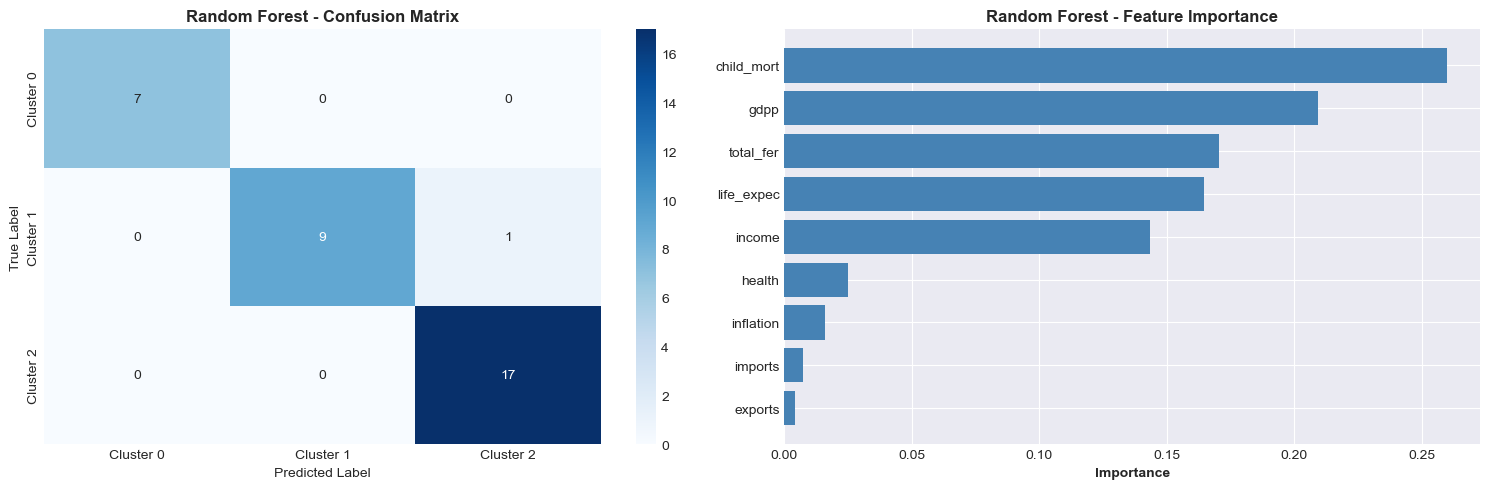

In [44]:
# Visualize Random Forest Results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion Matrix
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
           xticklabels=[f'Cluster {i}' for i in np.unique(y)],
           yticklabels=[f'Cluster {i}' for i in np.unique(y)])
axes[0].set_title('Random Forest - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Feature Importance
feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

axes[1].barh(feature_importance_rf['Feature'], feature_importance_rf['Importance'], color='steelblue')
axes[1].set_xlabel('Importance', fontweight='bold')
axes[1].set_title('Random Forest - Feature Importance', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


## 11. XGBoost Classification


In [45]:
# XGBoost Classifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)

print("✓ XGBoost model trained successfully")

✓ XGBoost model trained successfully


In [46]:
# Evaluate XGBoost
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb, average='weighted')
xgb_recall = recall_score(y_test, y_pred_xgb, average='weighted')
xgb_f1 = f1_score(y_test, y_pred_xgb, average='weighted')

print("\nXGBOOST EVALUATION METRICS")
print("="*60)
print(f"Accuracy:  {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1 Score:  {xgb_f1:.4f}")

print("\nCONFUSION MATRIX")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_xgb, target_names=[f'Cluster {i}' for i in np.unique(y)]))


XGBOOST EVALUATION METRICS
Accuracy:  0.9706
Precision: 0.9722
Recall:    0.9706
F1 Score:  0.9702

CONFUSION MATRIX
[[ 7  0  0]
 [ 0  9  1]
 [ 0  0 17]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00         7
   Cluster 1       1.00      0.90      0.95        10
   Cluster 2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



### Observation

Both Random Forest and XGBoost achieved identical performance with 97.06% accuracy. This indicates that the generated clusters are well-defined and can be effectively predicted using ensemble learning techniques.

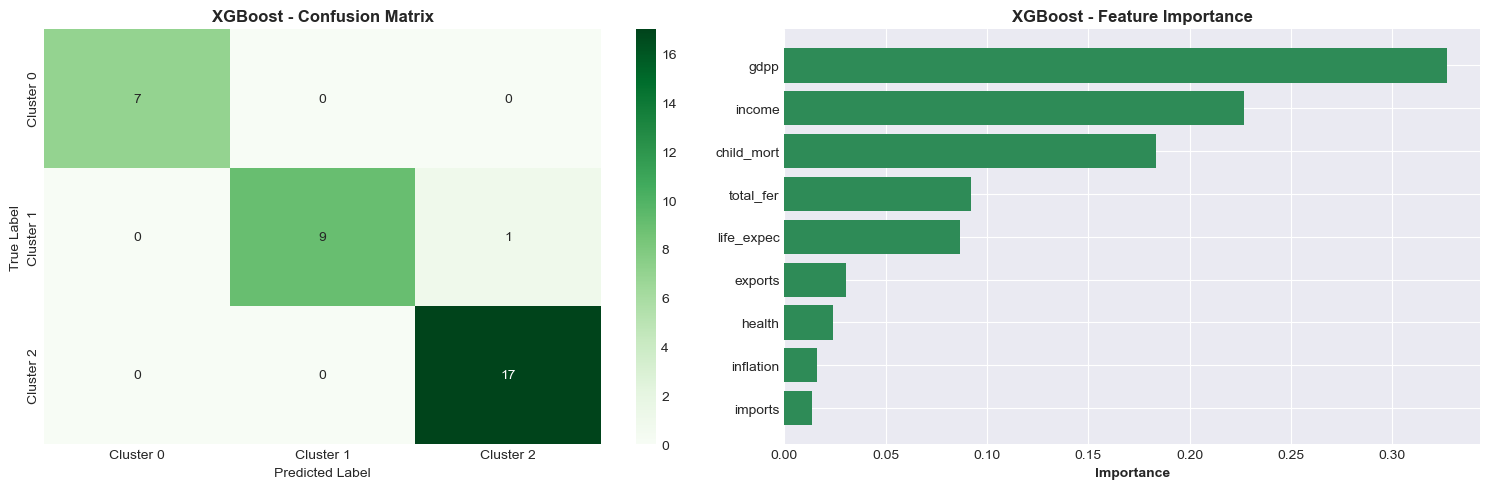

In [47]:
# Visualize XGBoost Results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion Matrix
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[0],
           xticklabels=[f'Cluster {i}' for i in np.unique(y)],
           yticklabels=[f'Cluster {i}' for i in np.unique(y)])
axes[0].set_title('XGBoost - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Feature Importance
feature_importance_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

axes[1].barh(feature_importance_xgb['Feature'], feature_importance_xgb['Importance'], color='seagreen')
axes[1].set_xlabel('Importance', fontweight='bold')
axes[1].set_title('XGBoost - Feature Importance', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 12. Ensemble Learning Comparison


In [48]:
# Ensemble Model Comparison

comparison_table = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [rf_accuracy, xgb_accuracy],
    'Precision': [rf_precision, xgb_precision],
    'Recall': [rf_recall, xgb_recall],
    'F1 Score': [rf_f1, xgb_f1]
})

display(comparison_table.round(4))

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.9706,0.9722,0.9706,0.9702
1,XGBoost,0.9706,0.9722,0.9706,0.9702


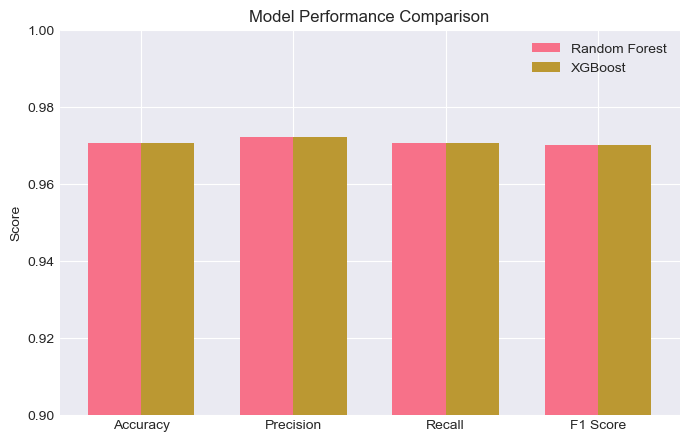

In [49]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

rf_scores = [rf_accuracy, rf_precision, rf_recall, rf_f1]
xgb_scores = [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, rf_scores, width, label='Random Forest')
plt.bar(x + width/2, xgb_scores, width, label='XGBoost')

plt.xticks(x, metrics)
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.ylim(0.9, 1.0)
plt.legend()

plt.show()

### Final Recommendation

Both Random Forest and XGBoost achieved the same performance (97.06% accuracy). Since Random Forest is simpler to interpret and train, it can be selected as the preferred model. However, both models demonstrated excellent predictive capability.

## 13. Business Intelligence Insights


In [50]:
# Cluster Summary

df_analysis = df.copy()
df_analysis['cluster'] = kmeans_labels

cluster_summary = df_analysis.groupby('cluster')[X.columns].mean().round(2)

print("CLUSTER SUMMARY")
display(cluster_summary)

CLUSTER SUMMARY


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


## Business Insights

### Cluster 0 - Developed Countries
- Highest GDP per capita (~42,494)
- Highest income levels (~45,672)
- High life expectancy (~80 years)
- Very low child mortality (~5)

**Insight:** Economically advanced countries with strong healthcare and living standards.

---

### Cluster 1 - Developing / High-Risk Countries
- Lowest GDP per capita (~1,922)
- Lowest income levels (~3,942)
- Highest child mortality (~93)
- Lowest life expectancy (~59 years)

**Insight:** Countries requiring greater focus on healthcare, education, and economic development.

---

### Cluster 2 - Emerging Economies
- Moderate GDP per capita (~6,486)
- Moderate income levels (~12,306)
- Improving life expectancy (~73 years)
- Lower child mortality than Cluster 1

**Insight:** Growing economies with potential for investment and infrastructure development.

---

### Key Finding
GDP per capita, income, child mortality, and life expectancy were the most important factors influencing country segmentation.

## 14. Conclusion

In this project, clustering and classification techniques were applied to analyze country-level socio-economic and health indicators.

K-Means clustering produced three meaningful country groups and outperformed DBSCAN based on clustering evaluation metrics. The generated cluster labels were then used to train Random Forest and XGBoost classifiers.

Both Random Forest and XGBoost achieved an accuracy of approximately 97%, demonstrating that the identified clusters are well-defined and can be predicted effectively.

Feature importance analysis showed that GDP per capita, income, child mortality, life expectancy, and fertility rate were the key factors influencing country segmentation.

Overall, the project successfully combined clustering and ensemble learning techniques to generate meaningful insights about country development patterns.
